Modified and verified by **Heejoon Moon**
- version: 11.28

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.listdir('/content/drive/MyDrive'))


['ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦Ãƒâ€šÃ‚Â¥ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Ãƒâ€šÃ‚Â·ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾ÃƒÂ¢Ã¢â€šÂ¬Ã‹Å“ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦Ãƒâ€šÃ‚Â²ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦Ãƒâ€šÃ‚Â¥ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¡ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦Ãƒâ€šÃ‚ÂµÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€¦Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦Ãƒâ€šÃ‚Â¥ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Ãƒâ€šÃ‚Â«ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦Ãƒâ€šÃ‚Â©ÃƒÆ’Ã‚Â¡ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Ãƒâ€šÃ‚Â«', 'Colab Notebooks', 'Toa_test_sort.csv', 'Toa_sort.csv', '.ipynb_checkpoints', 'npy_dataset']


In [ ]:
source_path = '/content/drive/MyDrive/컴퓨터비전개론'\nprint(os.listdir(source_path))          # ['train', 'val'] ë‚˜ì™€ì•¼ í•¨
print(os.listdir(source_path + '/train'))  # ['Fight', 'NonFight'] ë“±


## **0. Preprocessing Data**
- concat RGB frames and opticalflow
- transform videos to '.npy' format
  - '.npy' has 5 channels -> RGB (3) and opticalflow ((u, v) -> 2)
  - you can use another opticalflow algorithms

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

def getOpticalFlow(video):
    """Calculate dense optical flow of input video
    Args:
        video: the input video with shape of [frames,height,width,channel]. dtype=np.array
    Returns:
        flows_x: the optical flow at x-axis, with the shape of [frames,height,width,channel]
        flows_y: the optical flow at y-axis, with the shape of [frames,height,width,channel]
    """
    gray_video = []
    for i in range(len(video)):
        img = cv2.cvtColor(video[i], cv2.COLOR_RGB2GRAY)
        gray_video.append(np.reshape(img, (224, 224, 1)))

    flows = []
    for i in range(0, len(video) - 1):
        flow = cv2.calcOpticalFlowFarneback(gray_video[i], gray_video[i + 1], None, 0.5, 3, 15, 3, 5, 1.2,
                                            cv2.OPTFLOW_FARNEBACK_GAUSSIAN)
        flow[..., 0] -= np.mean(flow[..., 0])
        flow[..., 1] -= np.mean(flow[..., 1])
        flow[..., 0] = cv2.normalize(flow[..., 0], None, 0, 255, cv2.NORM_MINMAX)
        flow[..., 1] = cv2.normalize(flow[..., 1], None, 0, 255, cv2.NORM_MINMAX)
        flows.append(flow)

    flows.append(np.zeros((224, 224, 2)))

    return np.array(flows, dtype=np.float32)


def Video2Npy(file_path, resize=(224,224)):
    """Load video and tansfer it into .npy format
    Args:
        file_path: the path of video file
        resize: the target resolution of output video
    Returns:
        frames: gray-scale video
        flows: magnitude video of optical flows
    """
    cap = cv2.VideoCapture(file_path)
    len_frames = int(cap.get(7))
    try:
        frames = []
        for i in range(len_frames-1):
            _, frame = cap.read()
            frame = cv2.resize(frame,resize, interpolation=cv2.INTER_AREA)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = np.reshape(frame, (224,224,3))
            frames.append(frame)
    except:
        print("Error: ", file_path, len_frames,i)
    finally:
        frames = np.array(frames)
        cap.release()

    flows = getOpticalFlow(frames)

    optical_flow_map = farneback_visual(flows)

    result = np.zeros((len(flows),224,224,5))
    result[...,:3] = frames
    result[...,3:] = flows

    return result

def farneback_visual(flows):
    pass


def Save2Npy(file_dir, save_dir):
    """Transfer all the videos and save them into specified directory
    Args:
        file_dir: source folder of target videos
        save_dir: destination folder of output .npy files
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    videos = os.listdir(file_dir)
    for v in tqdm(videos):
        video_name = v.split('.')[0]
        video_path = os.path.join(file_dir, v)
        save_path = os.path.join(save_dir, video_name+'.npy')
        data = Video2Npy(file_path=video_path, resize=(224,224))
        data = np.uint8(data)
        np.save(save_path, data)

    return None

### convert data and save it (offline)

In [ ]:
source_path = '/content/drive/MyDrive/컴퓨터비전개론'
target_path = '/content/drive/MyDrive/컴퓨터비전개론'


for f1 in ['train', 'val']:
    for f2 in ['Fight', 'NonFight']:
        path1 = os.path.join(source_path, f1, f2)
        path2 = os.path.join(target_path, f1, f2)
        Save2Npy(file_dir=path1, save_dir=path2)

 19%|â–ˆâ–‰        | 31/160 [03:50<15:57,  7.42s/it]


KeyboardInterrupt: 

## **1. Build Data Loader**

In [ ]:
import torch
import torch.utils.data as data
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import cv2

class DataGenerator(Dataset):

    def __init__(self, directory, data_augmentation=True, phase='train'):
        self.phase=phase
        self.directory = directory
        self.data_aug = data_augmentation
        self.X_path, self.Y_dict = self.search_data()
        self.print_stats()

    def __len__(self):
        steps_per_epoch = int(len(self.X_path))
        return steps_per_epoch

    def __getitem__(self, index):
        data, label = self.data_generation(self.X_path[index])
        return data.float(), label


    def load_data(self, path):
        data = np.load(path, mmap_mode='r') # \n        data = self.uniform_sampling(data, target_frames=64) # Randomly sample number of target frames
        if self.data_aug: # If data is augmented...
            data[..., :3] = self.color_jitter(data[..., :3])
            data = self.random_flip(data, prob=0.5) # Random flip image into random direction
        data[..., :3] = self.normalize(data[..., :3]) # Normalize RGB
        data[..., 3:] = self.normalize(data[..., 3:]) # Normalize optical flows
        return data

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def normalize(self, data):
        mean = data.mean()
        std = data.std()
        return (data - mean) / std

    def random_flip(self, video, prob):
        s = np.random.rand()
        if s < prob:
            video = np.flip(video, (2,)) # Flip in width direction
        return video

    def uniform_sampling(self, video, target_frames=64):
        len_frames = int(len(video))
        interval = int(np.ceil(len_frames/target_frames))
        sampled_video = []
        for i in range(0,len_frames,interval):
            sampled_video.append(video[i])
        num_pad = target_frames - len(sampled_video) # num pad = # target frame - # current frame
        padding = []
        if num_pad>0:
            for i in range(-num_pad,0):
                try:
                    padding.append(video[i]) # \n                except:
                    padding.append(video[0])
            sampled_video += padding # Add padding results
        return np.array(sampled_video, dtype=np.float32)

    def color_jitter(self, video):
        s_jitter = np.random.uniform(-0.2, 0.2)
        v_jitter = np.random.uniform(-30, 30)
        for i in range(len(video)):
            hsv = cv2.cvtColor(np.array(video[i]), cv2.COLOR_RGB2HSV) # Convert RGB -> HSV
            s = hsv[..., 1] + s_jitter # saturation jitter
            v = hsv[..., 2] + v_jitter # \n            s[s < 0] = 0
            s[s > 1] = 1
            v[v < 0] = 0
            v[v > 255] = 255
            hsv[..., 1] = s # set jittered saturation
            hsv[..., 2] = v # \n            video[i] = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB) # Convert HSV -> RGB again
        return video

    def print_stats(self):
            self.n_files = len(self.X_path)
            self.n_classes = len(self.dirs)
            self.indexes = np.arange(len(self.X_path))
            np.random.shuffle(self.indexes)
            print("Found {} files belonging to {} classes.".format(self.n_files, self.n_classes))
            for i, label in enumerate(self.dirs):
                print('{:10s} : {}'.format(label, i))


    def search_data(self):
        X_path = []
        Y_dict = {}

        self.dirs = sorted(os.listdir(self.directory))\n        one_hots = np.eye(len(self.dirs), dtype=np.float32) \n
        for i, folder in enumerate(self.dirs):
          folder_path = os.path.join(self.directory, folder)  # folder_path = .../train/Fight or .../train/NonFight
          for file in os.listdir(folder_path):
                if not file.endswith('.npy'):
                    continue
                file_path = os.path.join(folder_path, file)

                X_path.append(file_path)                      \n
                Y_dict[file_path] = one_hots[i]               \n
        return X_path, Y_dict

    def data_generation(self, batch_path):
        video = self.load_data(batch_path)       # numpy array (T,H,W,5)
        label = self.Y_dict[batch_path]         # numpy array (num_classes,)

        video = np.ascontiguousarray(video)
        label = np.ascontiguousarray(label)

        video = torch.from_numpy(video).float()
        label = torch.from_numpy(label).float()
        return video, label

## \n- this model is 'Flow Gated Network' proposed in 'RWF2000'
- you can use off-the-shelf architectures such as ResNet, EfficientNet, etc.
- model structure is produced in below image
- Fully-Connected layer is little bit different with image, so we provide Fully-Connected layer structure



In [ ]:
'''
import torch
import torch.nn as nn
import torch.nn.functional as F

class FusionModel(nn.Module):
    def __init__(self):
        super(FusionModel, self).__init__()
        self.relu=nn.ReLU(inplace=True)

        self.rgb_block = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),     # ÃƒÆ’Ã‚ÂªÃƒâ€šÃ‚Â³Ãƒâ€šÃ‚ÂµÃƒÆ’Ã‚ÂªÃƒâ€šÃ‚Â°ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾ÃƒÆ’Ã‚Â«Ãƒâ€šÃ‚Â§Ãƒâ€¦Ã¢â‚¬â„¢ downsample

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),     # ÃƒÆ’Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¹Ãƒâ€¦Ã¢â‚¬Å“ÃƒÆ’Ã‚ÂªÃƒâ€šÃ‚Â³Ãƒâ€šÃ‚ÂµÃƒÆ’Ã‚ÂªÃƒâ€šÃ‚Â°ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾ downsample
        )
        self.opt_block = nn.Sequential(
            nn.Conv3d(2, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),
        )
        self.merge_block = nn.Sequential(
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1)) \n        )
        self.fc1 = nn.Linear(128, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 32)
        self.fc3 = nn.Linear(32, 2)

        self.__init_weight()

    def forward(self, x):
        x = x.transpose(2,4)
        x = x.transpose(3,4)
        x = x.transpose(1,2)
        rgb = x[:,:3,:,:,:]
        opt = x[:,3:5,:,:,:]

        rgb = self.rgb_block(rgb)
        opt = self.opt_block(opt)
        fused = rgb * opt
        fused = F.max_pool3d(fused, kernel_size=2, stride=2)

        merged = self.merge_block(fused)

        x = merged.view(merged.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

    def __init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.BatchNorm3d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
'''

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class EfficientFusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super(EfficientFusionModel, self).__init__()

        weights = models.EfficientNet_B0_Weights.DEFAULT
        self.rgb_backbone = models.efficientnet_b0(weights=weights)

        self.rgb_backbone.classifier = nn.Identity()
        self.opt_backbone = models.efficientnet_b0(weights=weights)
        self.opt_backbone.classifier = nn.Identity()

        first_conv = self.opt_backbone.features[0][0]
        new_first_conv = nn.Conv2d(
            in_channels=2,
            out_channels=first_conv.out_channels,
            kernel_size=first_conv.kernel_size,
            stride=first_conv.stride,
            padding=first_conv.padding,
            bias=False
        )

        with torch.no_grad():
            new_first_conv.weight[:] = torch.mean(first_conv.weight, dim=1, keepdim=True)

        self.opt_backbone.features[0][0] = new_first_conv

        self.fusion_fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280 * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        if x.dim() == 5 and x.shape[-1] == 5:
            x = x.permute(0, 4, 1, 2, 3) # \n
        b, c, t, h, w = x.size()

        rgb = x[:, :3, :, :, :]\n        opt = x[:, 3:5, :, :, :] # \n
        rgb = rgb.permute(0, 2, 1, 3, 4).reshape(b * t, 3, h, w)
        opt = opt.permute(0, 2, 1, 3, 4).reshape(b * t, 2, h, w)

        rgb_feat = self.rgb_backbone(rgb)
        opt_feat = self.opt_backbone(opt)

        rgb_feat = rgb_feat.view(b, t, -1)
        opt_feat = opt_feat.view(b, t, -1)

        rgb_feat = torch.mean(rgb_feat, dim=1) # \n        opt_feat = torch.mean(opt_feat, dim=1) # \n
        fused = torch.cat((rgb_feat, opt_feat), dim=1) # \n
        out = self.fusion_fc(fused)

        return out

## **3. Training the Model**
- set hyper-parameters for training

In [8]:
!pip install wandb

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
from tqdm import tqdm
import wandb
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# \n# define model, optimizer and criterion
# \nmodel = FusionModel().to(device)                        \noptimizer = optim.SGD(                                  \n    model.parameters(),
    lr=0.003,
    weight_decay=1e-6,
    momentum=0.9,
    nesterov=True,
)
loss_fn = nn.CrossEntropyLoss()                         \n
# \nscheduler = StepLR(optimizer, step_size=10, gamma=0.7)

# ë°ì´í„° ê²½ë¡œ (npy_dataset ê¸°ì¤€)
trainset_path = '/content/drive/MyDrive/컴퓨터비전개론/train'
validation_path = '/content/drive/MyDrive/컴퓨터비전개론/val'

# \n# define dataset and dataloader
# \ntrain_dataset = DataGenerator(trainset_path,  phase='train', data_augmentation=True)
val_dataset   = DataGenerator(validation_path, phase='val',   data_augmentation=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# assign device cpu or gpu
min_loss = np.inf

# \n# learning rate = 0.003

# \n# \n# momentum = 0.9
# nesterov = True
# \n
# loss = CrossEntropy



Found 160 files belonging to 2 classes.
Fight      : 0
NonFight   : 1
Found 40 files belonging to 2 classes.
Fight      : 0
NonFight   : 1


In [21]:
def _train(self):
    model.train()
    acc_temp = 0
    running_loss = 0


    train_acc = acc_temp / len(train_loader.dataset)
    train_loss = running_loss / len(train_loader.dataset)

    return train_acc, train_loss

In [22]:
def _val(self):
    model.eval()
    with torch.no_grad():
        running_loss_val = 0
        acc_temp_val =0


        val_acc = acc_temp_val / len(val_loader.dataset)
        val_loss = running_loss_val / len(val_loader.dataset)

    return val_acc, val_loss

In [ ]:
import random
import numpy as np

seed=0
random.seed(seed)
np.random.seed(seed)
device='cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(seed)
if device =='cuda':
    print('gpu device is using')
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False
num_epochs = 30

wandb.login()
wandb.init(project='computer vision', name=\u0027컴퓨터비전개론\u0027)

for epoch in range(num_epochs):
    print(f"Epoch [{epoch+1}/{num_epochs}] 시작!")
    # Perform training and validation
    train_loss = 0
    val_loss = 0

    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = loss_fn(pred, y)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    # Log training and validation results
    wandb.log({"train_loss": avg_train_loss, "val_loss": avg_val_loss})
    save_dir = '/content/drive/MyDrive/컴퓨터비전개론/models'
  \n    if avg_val_loss < min_loss:
        min_loss = avg_val_loss
        save_path = os.path.join(save_dir, f'FusionModel_{epoch}.pth')
        torch.save(model.state_dict(), save_path)
        print(f"Best model updated at epoch {epoch}")





wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


gpu device is using


Epoch [1/30] ì‹œìž‘!
Best model updated at epoch 0
Epoch [2/30] ì‹œìž‘!
Best model updated at epoch 1
Epoch [3/30] ì‹œìž‘!
Best model updated at epoch 2
Epoch [4/30] ì‹œìž‘!
Epoch [5/30] ì‹œìž‘!
Epoch [6/30] ì‹œìž‘!
Epoch [7/30] ì‹œìž‘!
Epoch [8/30] ì‹œìž‘!
Epoch [9/30] ì‹œìž‘!
Epoch [10/30] ì‹œìž‘!
Epoch [11/30] ì‹œìž‘!
Best model updated at epoch 10
Epoch [12/30] ì‹œìž‘!
Epoch [13/30] ì‹œìž‘!
Epoch [14/30] ì‹œìž‘!
Epoch [15/30] ì‹œìž‘!
Epoch [16/30] ì‹œìž‘!
Epoch [17/30] ì‹œìž‘!
Epoch [18/30] ì‹œìž‘!
Epoch [19/30] ì‹œìž‘!
Epoch [20/30] ì‹œìž‘!
Epoch [21/30] ì‹œìž‘!
Epoch [22/30] ì‹œìž‘!
Epoch [23/30] ì‹œìž‘!
Epoch [24/30] ì‹œìž‘!
Epoch [25/30] ì‹œìž‘!
Epoch [26/30] ì‹œìž‘!
Epoch [27/30] ì‹œìž‘!
Epoch [28/30] ì‹œìž‘!
Epoch [29/30] ì‹œìž‘!
Epoch [30/30] ì‹œìž‘!


In [ ]:
from torch.utils.data import DataLoader




best_model = '/content/drive/MyDrive/컴퓨터비전개론/models/FusionModel_10.pth'
test_path = '/content/drive/MyDrive/컴퓨터비전개론/val'

test_dataset = DataGenerator(directory=test_path, data_augmentation=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=0)

Found 40 files belonging to 2 classes.
Fight      : 0
NonFight   : 1


Accuracy: 0.7000
Accuracy: 0.7000
AUROC: 0.8600
AUROC: 0.8600


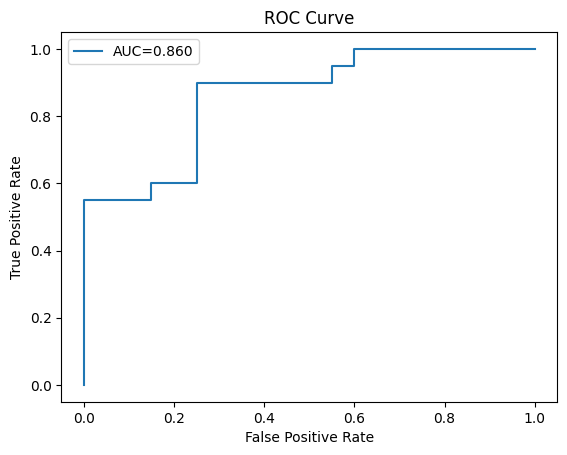

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(best_model, map_location=device))
model.eval()

y_true = []
y_score = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        pred = model(x)
        score = torch.softmax(pred, dim=1)[:,1].cpu().numpy()
        y_score.extend(score)
        y_true.extend(y.numpy())

# \npred_labels = (np.array(y_score) > 0.5).astype(int)
true_labels = np.argmax(np.array(y_true), axis=1)  # One-Hot -> Index ë³€í™˜
accuracy = (pred_labels == true_labels).mean()

print(f'Accuracy: {accuracy:.4f}')

print(f'Accuracy: {accuracy:.4f}')

# \ny_true_index = np.argmax(np.array(y_true), axis=1)

auc = roc_auc_score(y_true_index, y_score)
print(f'AUROC: {auc:.4f}')

# ROC Curve ê·¸ë¦´ ë•Œë„ ë³€í™˜ëœ y_true_indexë¥¼ ì¨ì•¼ í•©ë‹ˆë‹¤!
fpr, tpr, _ = roc_curve(y_true_index, y_score)
print(f'AUROC: {auc:.4f}')

# \nfpr, tpr, _ = roc_curve(y_true_index, y_score)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
